<a href="https://colab.research.google.com/github/NehaSrinivas98/MachineLearningCourse/blob/main/CourseContents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Missing values
## Types of missing values
* Missing Completely at Random (MCAR)
* Missing at Random (MAR)
* Missing Not at Random (MNAR)

##a. Missing Completely at Random (MCAR)

Data is missing completely randomly, and the missingness is not related to any variable in the dataset.

Example:
* A survey form gets damaged and some responses are lost.
* A sensor randomly fails to record temperature.

Characteristics:
* Missing values have no pattern.
* The missingness is independent of both observed and unobserved data.

Impact:
* Least problematic.
* You can safely use methods like listwise deletion or mean/median imputation.

##b. Missing at Random (MAR)

Missing data depends on other observed variables, but not on the missing value itself.
Example:
* Older people are less likely to reveal their income in a survey.
* Income is missing because of age, which is available in the dataset.
Characteristics:
* Missingness has a pattern related to another variable.
Impact Can be handled using:
* Regression imputation
* Multiple imputation
* Machine learning models

##c. Missing Not at Random (MNAR)

Missingness depends on the missing value itself.

Example:

* People with very high income refuse to disclose their salary.

* The probability of missing data depends on the actual income value.

Characteristics:

* Hardest type to handle.

* Missing data has a systematic bias.

Impact:

* Requires advanced modeling or domain knowledge.

# Handling missing values
##a. Delete Rows (Listwise Deletion)

* Remove rows that contain missing values.

* Example
<table>
  <tr>
    <th>
      Age
    </th>
    <th>
     Salary
    </th>
  </tr>
  <tr>
    <td>
      25
    </td>
    <td>
      40000
    </td>
  </tr>
  <tr>
    <td>
      30
    </td>
    <td>
      50000
    </td>
  </tr>
  <tr>
    <td>
      20
    </td>
    <td>
      Null
    </td>
  </tr>
</table>

* Use when the dataset is large missing values are very few and data is mcar
* Risk is loss of information

##b. Delete Columns
* Remove the entire column if too many values are missing.
* Use when Missing values > 40–50% and column is not important
* Example:
A column like middle_name may be removed.

##c. Mean Imputation
* Replace missing values with the mean of the column.
* Example:
20, 25, NaN, 30 ( mean = 25) replace nan with 25
* Use when Data is numerical and Distribution is normal

##d. Median Imputation
* Replace missing values with the median.
* Example: 30000,35000,Nan,900000 replace with median value 35000
* Use when Data has outliers and Median is more robust than mean.

##e. Mode Imputation
* Replace missing values with the most frequent value.
* Example:Male, Female, Male, NaN replace with Mode value Male
* Use when it is Categorical data

##f. Forward Fill (FFill)
* Use the previous value to fill missing data.
* Example: 100,Nan, 200 Fill with 100 value
*  Used in Time series data and stock prices

##g. Backward Fill (BFill)
* Use the next available value.
* Example: 100,Nan, 200 Fill with 200 value


##h. Interpolation
* Estimate missing values using a mathematical relationship between surrounding values.
* Example: 1, 2, NaN, 4 (Interpolated → 3)
* Common in Sensor data and Time series

##i. Predict Missing Values Using ML
* Use machine learning models to predict missing values.
* Example: Predict salary using the other features
* Models used is regression,decision trees,random forest

##j. Multiple Imputation
* Create multiple estimates for missing values and average them.
* Used in advanced statistical modeling.

#2. Imbalanced dataset
An imbalanced dataset occurs when the number of observations in different classes is not equal, especially in classification problems.

This situation is called Class Imbalance.

Handling imbalanced dataset
#a. Upsampling (Oversampling)

Increase the number of minority class samples.

Example:
* Duplicate minority samples
* Generate synthetic data
* One popular technique is Synthetic Minority Over-sampling Technique (SMOTE).

#b. Downsampling (Undersampling)

Reduce the number of majority class samples.

#c. Class Weighting

Give higher penalty to minority class errors.

Example in Python:

class_weight='balanced'

Used in models like:

* Logistic Regression

* Random Forest

* SVM

#d. Ensemble Methods
* An ensemble method combines multiple models to improve prediction performance.
* This concept is called Ensemble Learning.
* Instead of using one model, we combine many models.

* Use specialized algorithms such as Balanced Random Forest
EasyEnsemble

In [ ]:
# Example for upsampling
import numpy as np
import pandas as pd # Set the random seed for reproducibility
np.random.seed(123) # Create a dataframe with two classes
n_samples = 1000
class_0_ratio = 0.9
n_class_0 = int(n_samples * class_0_ratio)
n_class_1 = n_samples - n_class_0
print('n_class_0',n_class_0)
print('n_class_1',n_class_1)

n_class_0 900
n_class_1 100


* A seed is used to control randomness so that results can be reproduced.
* In programming and Machine Learning, many operations use random numbers, such as:

1. Data shuffling

2. Train-test splitting

3. Weight initialization in models

4. Random sampling

* Setting a seed ensures that the same random numbers are generated every time the program runs.

In [ ]:
## CREATE MY DATAFRAME WITH IMBALANCED DATASET
class_0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_0), # loc means 0 and scale means SD
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_0),
    'target': [0] * n_class_0 # generates 900 0's
})

class_1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=2, scale=1, size=n_class_1),
    'feature_2': np.random.normal(loc=2, scale=1, size=n_class_1),
    'target': [1] * n_class_1 # generates 100 1's
})
print('class0',class_0)
print('class1',class_1)

class0      feature_1  feature_2  target
0    -0.471276   0.328462       0
1     1.084072   1.038230       0
2    -0.379223   1.147064       0
3    -0.362274   0.638254       0
4    -0.681071  -1.075766       0
..         ...        ...     ...
895  -0.229982  -1.433189       0
896  -0.533514  -0.370110       0
897   0.060924  -0.284352       0
898   1.041367   0.373888       0
899  -0.862830   0.263030       0

[900 rows x 3 columns]
class1     feature_1  feature_2  target
0    1.775921   0.902553       1
1    2.338840   1.058241       1
2    1.728472   3.670939       1
3    3.365531   2.067791       1
4    1.262626   3.630785       1
..        ...        ...     ...
95   2.720690   1.978489       1
96   1.949078   3.709793       1
97   2.709784   3.324917       1
98   1.817689   1.549237       1
99   2.838910   2.240773       1

[100 rows x 3 columns]


In [ ]:
df=pd.concat([class_0,class_1]).reset_index(drop=True)

In [ ]:
df.tail()

,feature_1,feature_2,target
995,2.720690,1.978489,1
996,1.949078,3.709793,1
997,2.709784,3.324917,1
998,1.817689,1.549237,1
999,2.838910,2.240773,1


In [ ]:
df['target'].value_counts()

,count
target,
0,900
1,100


In [ ]:
df_minority=df[df['target']==1]
df_majority=df[df['target']==0]

In [ ]:
from sklearn.utils import resample
df_minority_upsampled=resample(df_minority,replace=True, #Sample With replacement
         n_samples=len(df_majority),
         random_state=42
        )

In [ ]:
df_minority_upsampled.shape

(900, 3)

In [ ]:
df_majority.shape

(900, 3)

In [ ]:
df_upsampled=pd.concat([df_majority,df_minority_upsampled])

In [ ]:
df_upsampled['target'].value_counts()

,count
target,
0,900
1,900


In [ ]:
# Downsampling
import pandas as pd

# Set the random seed for reproducibility
np.random.seed(123)

# Create a dataframe with two classes
n_samples = 1000
class_0_ratio = 0.9
n_class_0 = int(n_samples * class_0_ratio)
n_class_1 = n_samples - n_class_0

class_0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_0),
    'target': [0] * n_class_0
})

class_1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=2, scale=1, size=n_class_1),
    'feature_2': np.random.normal(loc=2, scale=1, size=n_class_1),
    'target': [1] * n_class_1
})

df = pd.concat([class_0, class_1]).reset_index(drop=True)

# Check the class distribution
print(df['target'].value_counts())

target
0    900
1    100
Name: count, dtype: int64


In [ ]:
df_minority=df[df['target']==1]
df_majority=df[df['target']==0]

In [ ]:
df_majority_downsampled = resample(
    df_majority,
    replace=False,      # sample without replacement
    n_samples=len(df_minority),
    random_state=42
)

# combine datasets
df_balanced = pd.concat([df_majority_downsampled, df_minority])

In [ ]:
df_balanced['target'].value_counts()

,count
target,
0,100
1,100


Smote
* SMOTE (Synthetic Minority Over-sampling Technique) is a data augmentation method used in machine learning to address class imbalance—a scenario where one category in a dataset (the majority) significantly outnumbers another (the minority).

* Unlike simple oversampling, which just duplicates existing records, SMOTE creates new, synthetic samples for the minority class to help models learn its patterns more effectively.

* 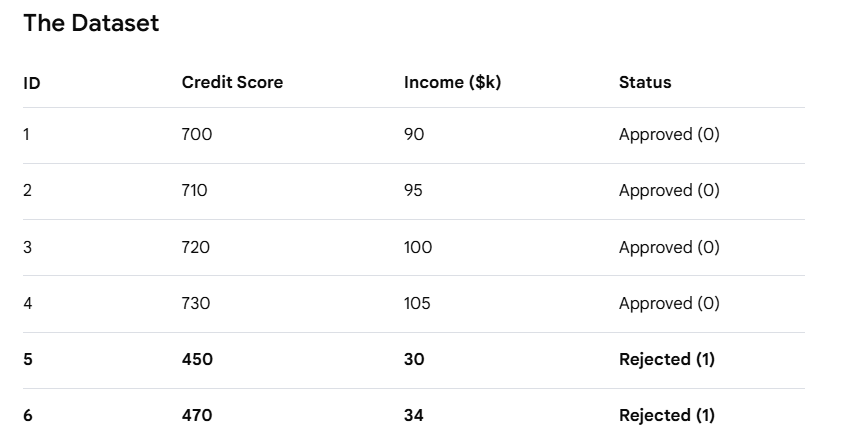
* Instead of just copying point 5 or 6, SMOTE draws a line between them and picks a random spot. The formula is:

 Synthetic = PointA + random(0,1)* (PointB- PointA)
 1. Select Point A: (450, 30)
 2. Select Point B (a neighbor): (470, 34)
 3. Calculate Difference: (470-450=20,34-30=4)
 4. Create a new point: Suppose random = 0.4 then new record is 450+(0.4*20) = 458 for credit and 30+(0.4*4) = 31.6 for income
 5. Similar way multiple points will be generated with the help of different randoms

Variants of smote
To make these clear, let’s use a tiny Credit Card Fraud dataset with 100 Legit transactions and 10 Fraud transactions.
1. Borderline-SMOTE: The "Edge Finder"

* The Problem: Normal SMOTE creates synthetic data for all 10 frauds, even the "obvious" ones.

* The Example: 8 of your fraud cases are clearly suspicious. 2 are "borderline" (they look almost like legit purchases).

* The Action: Borderline-SMOTE ignores the 8 obvious ones and creates all 90 new synthetic points around those 2 "borderline" cases to help the model learn the tricky difference.
2. ADASYN: The "Difficulty Specialist"
* The Problem: Some fraud cases are harder to catch than others.
* The Example: You have one fraud case surrounded by 10 legit transactions (very hard to spot). You have another fraud case surrounded by only 2 legit transactions (easier).
* The Action: ADASYN will generate more synthetic points around the "hard" fraud case and fewer around the "easy" one, forcing the model to study the difficult area more.
3. SMOTE-NC: The "Categorical Mixer"
* The Problem: You can't "average" a Transaction Type like Online and In-Store.
* The Example: Fraud A is $50 and Online. Fraud B is $100 and Online.
* The Action: It averages the math  but keeps the category Online (the most common among neighbors) rather than trying to create a non-existent "half-online" category.
4. SMOTE-Tomek: The "Cleaner"
* The Problem: SMOTE sometimes creates a "smudge" where fraud and legit points overlap.
* The Example: SMOTE creates a synthetic fraud point that is mathematically almost identical to a legit point.
* The Action: SMOTE-Tomek finds these "too-close" pairs (Tomek Links) and deletes both. This creates a clear "no-man's land" between classes so the model doesn't get confused.
5. K-Means SMOTE: The "Cluster Focus"
* The Problem: Fraud often happens in specific "zones" (e.g., high-value electronics or small gas station tests).
* The Example: You have two clusters of fraud: one at 2 AM and one for $500+ purchases.
* The Action: It groups the data into these two clusters first. It then generates synthetic data only inside those clusters, preventing it from creating "random" fraud points in areas where fraud never actually happens.

In [1]:
from sklearn.datasets import make_classification
X,y=make_classification(n_samples=1000,n_redundant=0,n_features=2,n_clusters_per_class=1,
                   weights=[0.90],random_state=12)
# number of samples = 1000
# n_redundant = Number of features that are linear combinations of informative features. f3 = f1+f2
# n_features = number of features f1 and f2
# n_clusters_per_class = it defines the number of clusters within each class
# weights = creates an imbalanced dataset with 90% data in one class 10% in other class
print('X&Y',X,y)

X&Y [[-0.76289759 -0.70680807]
 [-1.07543571 -1.0511621 ]
 [-0.61011459 -0.90980157]
 ...
 [-1.32643852 -1.815178  ]
 [-0.83348573 -0.5146474 ]
 [-0.30287558 -0.57597532]] [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 1 1 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 1 0 0 0 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 

In [2]:
import pandas as pd
df1=pd.DataFrame(X,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
final_df=pd.concat([df1,df2],axis=1)
final_df.head()

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [3]:
final_df['target'].value_counts()

,count
target,
0,900
1,100


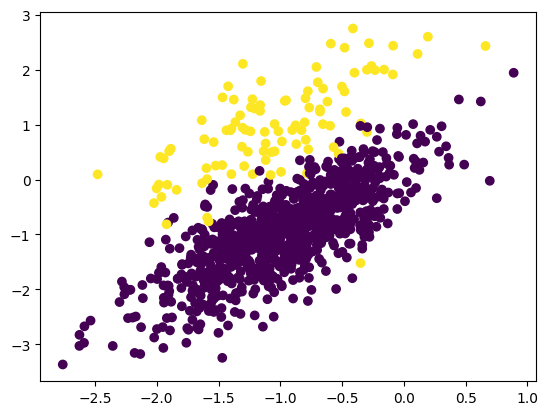

In [4]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'],final_df['f2'],c=final_df['target'])
# plt.scatter(x,y,color)

In [ ]:
!pip install imblearn

In [5]:
from imblearn.over_sampling import SMOTE

In [6]:
## transform the dataset
oversample=SMOTE()
X,y=oversample.fit_resample(final_df[['f1','f2']],final_df['target'])

In [7]:
print(X.shape)
print(y.shape)

(1800, 2)
(1800,)


In [8]:
len(y[y==0])

900

In [9]:
len(y[y==1])

900

In [10]:
df1=pd.DataFrame(X,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
oversample_df=pd.concat([df1,df2],axis=1)

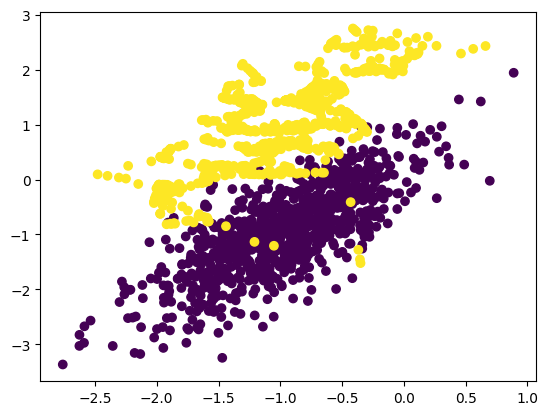

In [11]:
plt.scatter(oversample_df['f1'],oversample_df['f2'],c=oversample_df['target'])

#3. Handling outliers using python

In [12]:
import numpy as np

In [14]:
lst_marks=[45,32,56,75,89,54,32,89,90,87,67,54,45,98,99,67,74]
# minimum = 0
#Q1 = 0.25
#median = 0.50
#Q3 = 0.75
#maximum = 1.0
minimum,Q1,median,Q3,maximum=np.quantile(lst_marks,[0,0.25,0.50,0.75,1.0])

In [15]:
minimum,Q1,median,Q3,maximum

(np.float64(32.0),
 np.float64(54.0),
 np.float64(67.0),
 np.float64(89.0),
 np.float64(99.0))

In [16]:
IQR=Q3-Q1
print(IQR)

35.0


In [17]:
lower_fence=Q1-1.5*(IQR)
higher_fence=Q3+1.5*(IQR)

<Axes: >

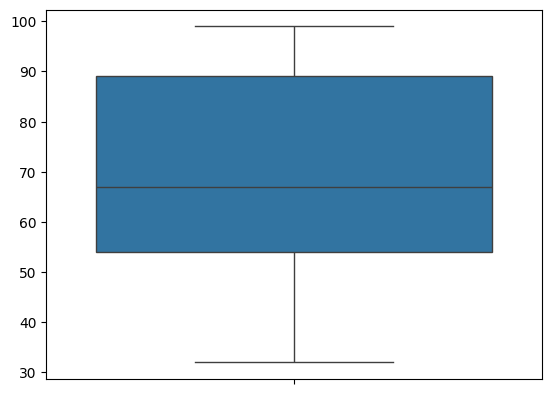

In [18]:
import seaborn as sns
sns.boxplot(lst_marks)

#4. Data Encoding
*  Nominal/OHE Encoding
*  Label and Ordinal Encoding
* Target Guided Ordinal Encoding

##a. Nominal/OHE Encoding
One hot encoding, also known as nominal encoding, is a technique used to represent categorical data as numerical data, which is more suitable for machine learning algorithms. In this technique, each category is represented as a binary vector where each bit corresponds to a unique category. It is used when the data has no orders. For example, if we have a categorical variable "color" with three possible values (red, green, blue), we can represent it using one hot encoding as follows:

 Red: [1, 0, 0]

 Green: [0, 1, 0]

 Blue: [0, 0, 1]

1. Advantages
* Nominal encoding does not introduce order between categories.
* Works Well With Many ML Algorithms
* Simple and Easy to Understand
* Improves Model Interpretation

2. Disadvantage
* Curse of dimensionality :If a feature has many unique categories, the number of columns increases dramatically.
* Sparse Dataset : most of the values are 0
* Multicollinearity Problem :One-hot encoding can create dummy variable trap. Suppose gender column holds a value M represented by 0 and F represented by 1. If we know the value of M its easy to predict the value of F
* Inefficient for large number of features

##b. Label Encoding
* Uses numbers to represent categories
* Mumbai, Delhi, Bangalore can be represented as 0,1,2

1. Advantages
* Easy to use
* Uses only 1 column

2. Disadvantages
* Introduces false ordering

3. Best use
* Use when feature has some order

##c. Ordinal Encoding
* Used when categories have natural order.
* High school,PHD,Masters -> 0,1,2

1. Advantages
* Uses one column
* keeps logical order

2. Disadvantage
* Distance between categories may not be meaningful.

3. Best use when:
* Data has natural ranking

##d. Frequency Encoding
* Categories are replaced by how frequently they appear.
* Mumbai,Delhi,Mumbai,Bangalore -> 2,1,2,1 // because mumbai has appeared twice

1. Advantages
* Uses single column
* Works well for high-cardinality features(cardinality means number of unique values in a featue

2. Disadvantage
* Different categories may get same value.

##e. Target encoding
* Category is replaced by the mean of the target variable.
* City : Delhi,Mumbai,Bangalore,Bangalore,Bangalore,Mumbai

  Price : 10,20,30,40,50,60

  result : Delhi = 10/1 = 10, Mumbai = 20+60/2 = 40, Bangalore = 30+40+50/3 = 40

1. Advantages
* Works well when a feature has many categories.
* It uses information from the target variable, which can improve model performance.
* Instead of creating many columns like one-hot encoding, target encoding produces only one numeric column.

2. Disadvantage
* If target encoding is applied before splitting data, the model may indirectly see the test data.
* If target encoding is applied before splitting data, the model may indirectly see the test data.
* Small datasets or rare categories can produce unstable averages.
* Compared to one-hot encoding, encoded values may not be intuitive.

##f. Hash Encoding
* Hash encoding uses a hash function to convert categories into numbers and then map them into a fixed number of columns.This technique is known as Feature Hashing.
* Suppose there is an example delhi,mumbai,bangalore,chennai. One hot encoding would create it as [1,0,0,0], [0,1,0,0],[0,0,1,0],[0,0,0,1]
If there are 10,000 cities, we would get 10,000 columns ❌.Hash encoding solves this.
* Convert each category into large number 2356,9812,6721,3451
* Use modulous operator to map 2356%4 = 0 hence h0 , 9812%4 = 0,6712%4=1,3451%4=3
* Two different categories mapped to the same column.This is called a collision.Collisions are expected in hash encoding.

In [2]:
# nominal/OHE encoding
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
## Create a simple dataframe
df = pd.DataFrame({
    'color': ['red', 'blue', 'green', 'green', 'red', 'blue']
})
df.head()
##create an instance of Onehotencoder
encoder=OneHotEncoder()
## perform fit and transform
encoded=encoder.fit_transform(df[['color']]).toarray()
print('encoded',encoded)

encoded [[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]


In [4]:
import pandas as pd
encoder_df=pd.DataFrame(encoded,columns=encoder.get_feature_names_out())
encoder_df

,color_blue,color_green,color_red
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,0.0,1.0
5,1.0,0.0,0.0


In [5]:
## for new data
encoder.transform([['blue']]).toarray()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


array([[1., 0., 0.]])

In [6]:
pd.concat([df,encoder_df],axis=1)

,color,color_blue,color_green,color_red
0,red,0.0,0.0,1.0
1,blue,1.0,0.0,0.0
2,green,0.0,1.0,0.0
3,green,0.0,1.0,0.0
4,red,0.0,0.0,1.0
5,blue,1.0,0.0,0.0


In [7]:
import seaborn as sns
sns.load_dataset('tips')

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [8]:
# label encoding
from sklearn.preprocessing import LabelEncoder
lbl_encoder=LabelEncoder()
print('fit transform',lbl_encoder.fit_transform(df[['color']]))
print('red',lbl_encoder.transform([['red']]))
print('blue',lbl_encoder.transform([['blue']]))
print('green',lbl_encoder.transform([['green']]))

fit transform [2 0 1 1 2 0]
red [2]
blue [0]
green [1]


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was

In [9]:
# Ordinal Encoding
from sklearn.preprocessing import OrdinalEncoder
df = pd.DataFrame({
    'size': ['small', 'medium', 'large', 'medium', 'small', 'large']
})
encoder=OrdinalEncoder(categories=[['small','medium','large']])
print('encoder',encoder)
print('transform',encoder.fit_transform(df[['size']]))
print('for small value',encoder.transform([['small']]))

encoder OrdinalEncoder(categories=[['small', 'medium', 'large']])
transform [[0.]
 [1.]
 [2.]
 [1.]
 [0.]
 [2.]]
for small value [[0.]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


In [10]:
# target encoding
import pandas as pd

# create a sample dataframe with a categorical variable and a target variable
df = pd.DataFrame({
    'city': ['New York', 'London', 'Paris', 'Tokyo', 'New York', 'Paris'],
    'price': [200, 150, 300, 250, 180, 320]
})
mean_price=df.groupby('city')['price'].mean().to_dict()
print('mean_price',mean_price)
df['city_encoded']=df['city'].map(mean_price)
print('df',df)
print('price and city encoded',df[['price','city_encoded']])

mean_price {'London': 150.0, 'New York': 190.0, 'Paris': 310.0, 'Tokyo': 250.0}
df        city  price  city_encoded
0  New York    200         190.0
1    London    150         150.0
2     Paris    300         310.0
3     Tokyo    250         250.0
4  New York    180         190.0
5     Paris    320         310.0
price and city encoded    price  city_encoded
0    200         190.0
1    150         150.0
2    300         310.0
3    250         250.0
4    180         190.0
5    320         310.0
